# **Comparative Analysis of Literary Translations in the Odyssey: Zipf's Law in Depth**

This is a comparative Zipf's Law analysis of six translations spanning roughly the last century: 1919–2018. 

## **Road Map**

### I. Libraries, files, and paths

### II. Zipf's Law Analysis

1. All-in, straightforward model  
    a) TTR Computation  
    b) Shapiro-Wilk test to check for normality  
    c) One-wat ANOVA for overall differences  
    d) Pairwise t-test using Bonferroni coprrection  
    c) Meassuring effect size ussing Cohen's d  

2. Adaptive models  
    a) Mixed-Effects model: author fixed effect / book as random effect  
    b) Standardized TTR:   
    c) Moving-average TTR: translation as temporal change  

3. Supplement models  
    a) Lexical Density   
    b) Diachronic analysis  
    c) Semantic fields:  

### IV. Discussing Results
    

## **I. Libraries, files, and paths**

In [1]:
#### Other libraries
import sys
import os

import ast
from collections import Counter

import re
import nltk

In [2]:
#### Pandas set-up
import numpy as np
import pandas as pd

In [3]:
#### Visualization
sys.path.append('/Users/debr/English-Homer') 
import matplotlib.pyplot as plt
import seaborn as sns
import bard_visualization as viz # My Vizualization library

Bard viz is on the stage!


In [4]:
# Import my functions
sys.path.append('/Users/debr/English-Homer/functions') 
import e_nlp as e

e enters! »----> use e.<function>

e.g., for pipeline:
		 nlp = e.NLPPipeline(language="english")

Stopwords customized:
  Added: {'four', 'three', 'one', "'and", 'n', 'six', 'five', 'seven', 'two', 'eight', 'ten', "'", 'nine'}
  Removed: {''}
  Total stopwords: 211
Punctuation customized:
  Keeping: {'', '-'}
  Additional removals: {'“', '‘', '—', '-', '…', '”', '\\', '’'}
  Punctuation to be removed: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~—‘’“”…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
#### Cell display options
pd.set_option("display.max_rows", 2000)  # Increase row display
pd.set_option("display.max_colwidth", 200)  # Prevent truncation of long values
pd.set_option("display.precision", 2)  # Display numbers with two decimal places
pd.set_option("display.float_format", "{:.2f}".format)  # Format float numbers
pd.set_option("display.max_columns", None)  # Show all columns
#pd.set_option("display.expand_frame_repr", False)  # Prevent wrapping in DataFrames
pd.set_option("display.width", 1000)  # Prevent wrapping in DataFrames
pd.set_option("colheader_justify", "left")

In [6]:
#### File management
# TO UPDATE
nb_id = "Zipf_Six_Modern"
translators = ["AT_Murray", "Fitzgerald", "Lattimore", "Fagles", "Wilson", "Green"]

# Paths
output_path = f"/Users/debr/English-Homer/{nb_id}/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

output_path_plots = f"{output_path}/{nb_id}_plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)

In [7]:
# Daframe with all the translators
dfs = []

for odyssey in translators:
    filepath = f"/Users/debr/odysseys_en/dataframed/Odyssey_{odyssey}_DataFrame.csv"
    temp_df = pd.read_csv(filepath)  
    dfs.append(temp_df)  # Append it to the list

df = pd.concat(dfs, axis=0, ignore_index=True)

df["text"] = df["text"].apply(ast.literal_eval)
df["tokens"] = df["tokens"].apply(ast.literal_eval)
df['translator'] = pd.Categorical(df['author'])
df["book_num"] = pd.Categorical(df["book_num"])
df = df[['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens']]
e.check_df(df)

Oh, yeah! No missing values here!

* df columns: Index(['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens'], dtype='object') 

* Shape: (144, 6) 

* Total memory: 3.490719


In [8]:
df.sample(4, random_state=4)

,translator,book_num,text,tokens,num_words,num_tokens
128,Green,9,"[Then resourceful Odysseus responded to him, saying:\n, “Alkinoos, lord, most distinguished among all peoples,\n, it is indeed a good thing to listen to such a minstrel\n, as this man is, who rese...","[resourceful, odysseus, responded, saying, alkinoos, lord, distinguished, among, peoples, indeed, good, thing, listen, minstrel, man, resembles, gods, singing, say, greater, fulfillment, pleasure,...",5950,2786
5,AT_Murray,6,"[So here Odysseus slept, overcome by sleep and\n, toil; but Athena went off to the demos and city of\n, the Phaeacians - a people who used to live in the fair town of Hypereia, near\n, the lawless...","[odysseus, slept, overcome, sleep, toil, athena, went, demos, city, phaeacians, people, used, live, fair, town, hypereia, near, lawless, cyclopes, cyclopes, stronger, force, plundered, king, nausi...",3470,1492
61,Lattimore,14,"[But Odysseus himself left the harbor and ascended a rugged\n, path, through wooded country along the heights, where Athene\n, had indicated the noble swineherd, who beyond others\n, cared for the...","[odysseus, left, harbor, ascended, rugged, path, wooded, country, along, heights, athene, indicated, noble, swineherd, beyond, others, cared, house, properties, acquired, noble, odysseus, found, s...",6328,2728
29,Fitzgerald,6,"[Far gone in weariness, in oblivion, \n, the noble and enduring man slept on; \n, but Athena in the night went down the land \n, of the Phaiakians, entering their city. \n, In days gone by, these ...","[far, gone, weariness, oblivion, noble, enduring, man, slept, athena, night, went, land, phaiakians, entering, city, days, gone, men, held, hypereia, country, wide, dancing, grounds, near, overbea...",2907,1454


In [9]:
print(f"* Text:\n", type(df["text"].iloc[0]))
print(df["text"].iloc[0][:2])
print("* Tokens:\n", type(df["tokens"].iloc[0]))
print(df["tokens"].iloc[0][:2])
mem_per_column = df.memory_usage(deep=True) / 1_000_000 # Size in MB
print(f"\n* Memory per column:\n{mem_per_column}") 
print("\n* Total memory:", df.memory_usage(deep=True).sum() / 1_000_000)

* Text:
 <class 'list'>
['Tell me, O Muse, of that many-sided hero who\n', 'traveled far and wide after he had sacked the famous town of Troy . Many cities did he visit, and many were\n']
* Tokens:
 <class 'list'>
['tell', 'muse']

* Memory per column:
Index        0.00
translator   0.00
book_num     0.00
text         0.63
tokens       2.86
num_words    0.00
num_tokens   0.00
dtype: float64

* Total memory: 3.490719


#### 2. **The translators**

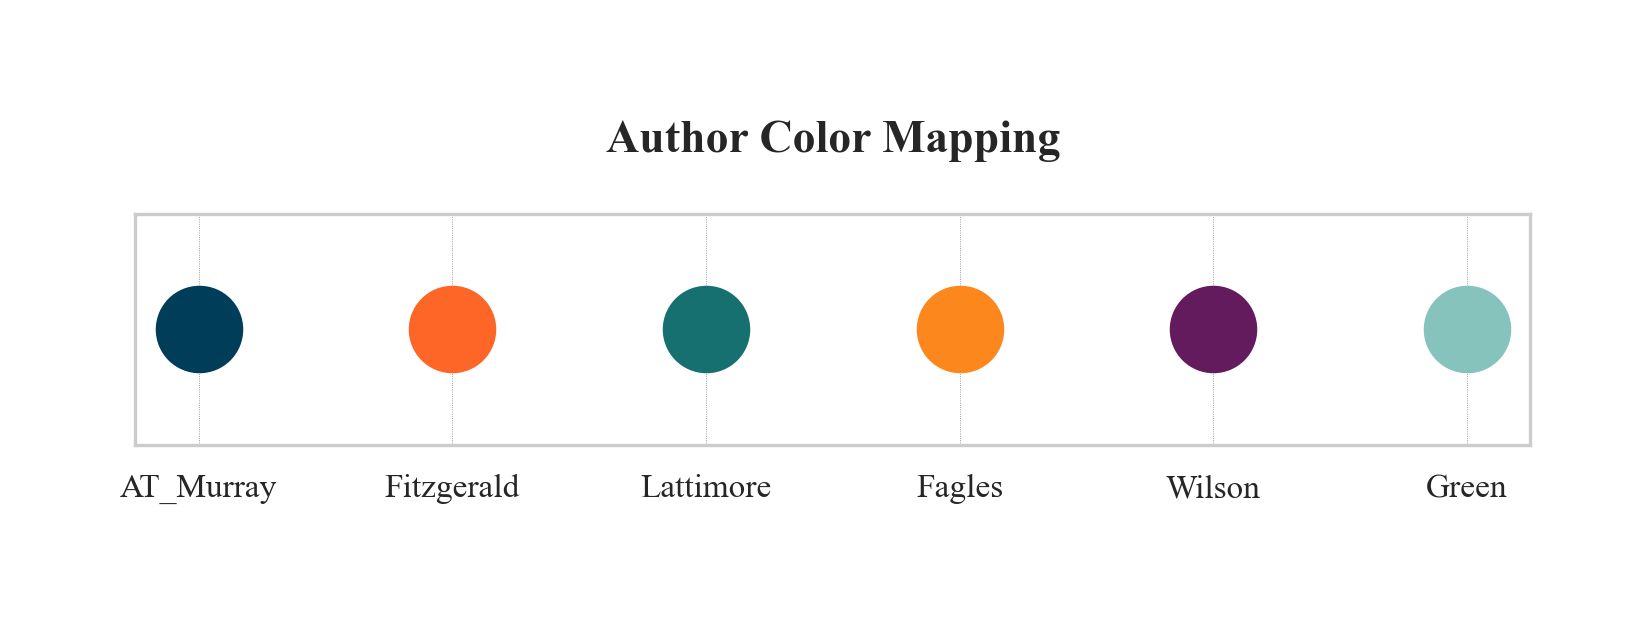

In [10]:
# Color mapping authors
palette = {author: color for author, 
           color in zip(translators, viz.color_palette.values())}

plt.figure(figsize=(6, 1))

for i, (author, color) in enumerate(palette.items()):
    plt.scatter(i, 0, color=color, s=400)

plt.xticks(range(len(palette)), palette.keys(), fontsize=8)
plt.yticks([])
plt.title("Author Color Mapping", fontsize=11)
plt.savefig(f"{output_path_plots}author_color_mapping-{nb_id}.png")
plt.show()

________________________________
## **II. Zipf’s Law Analysis**

### **What and why:** 

Zipf’s Law states that in a large text corpus, the frequency of a word is inversely proportional to its rank in the frequency table. This metric is relevant in comparing translations because it reveals how each translator balances **common vs. rare words**, shedding light on **lexical richness and stylistic choices**. This experiment provides empirical insight into whether a translator’s lexical distribution align with universal linguistic principles.


### **Implications for Translation Studies**

**a) natural linguistic flow:** Strong Zipfian adherence suggests that translators maintain natural language patterns, balancing high-frequency function words with low-frequency content words.  

**b.1) Poetic stylization:** Deviations may indicate differences in lexical richness, syntactic choices, or stylistic adaptation in translation.  
**b.2) Philological fidelity:** 'Stylistic' shifts can also point out to genre requirements that, in the case of epic oral poetry, demand disticnt repetitive and formulaic patterns, epithets, etc.



### **Implementation** 

Zipf’s Law states that in any natural language corpus, *the frequency of a word is inversely proportional to its rank:* 


$$ f \propto \frac{1}{r} $$

Where:
* f = frequency of the word
* r = rank of the word (1st most frequent, 2nd most frequent, etc.)

Procedure:
1. Compute word frequencies for each translation.  
2. Rank words from most to least frequent.  
3. Plot word frequency vs. rank on a log-log scale. 


In [11]:
# Step 1: Flatten tokens and count word frequencies for each translator
freq_dict = {
    translator: Counter(
        token for tokens in df[df["translator"] == translator]["tokens"] for token in tokens
    )
    for translator in translators
}

# Step 2: Convert word frequencies into sorted DataFrames with rank
df_word_freq_rank_dict = {
    translator: pd.DataFrame(freq.items(), columns=["word", "frequency"])
    .sort_values(by="frequency", ascending=False)
    .assign(rank=lambda df_: df_["frequency"].rank(method="first", ascending=False))
    for translator, freq in freq_dict.items()
}

# Example: Accessing a specific translator’s Zipf DataFrame
df_word_freq_rank_dict["AT_Murray"].tail(15).T  # View the top-ranked words for AT_Murray

,3890,3891,3892,3893,3895,3897,3898,3903,3904,3905,3906,3907,3909,3910,6320
word,depends,noiselessly,threes,withies,ensconced,udders,backs,wont,mob,flowery,mead,bubbling,lag,nogood,parties
frequency,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
rank,6307.00,6308.00,6309.00,6310.00,6311.00,6312.00,6313.00,6314.00,6315.00,6316.00,6317.00,6318.00,6319.00,6320.00,6321.00


In [12]:
#freq_dict
#df_word_freq_rank_dict

In [13]:
# Print total number of tokens per translator
for translator in translators:
    total_tokens = sum(freq_dict[translator].values())
    print(f"{translator}: {total_tokens} tokens")

AT_Murray: 51047 tokens
Fitzgerald: 53418 tokens
Lattimore: 61716 tokens
Fagles: 61974 tokens
Wilson: 47705 tokens
Green: 59202 tokens


In [14]:
# Compute min and max ranks across all translators
min_rank = min(df["rank"].min() for df in df_word_freq_rank_dict.values())
max_rank = max(df["rank"].max() for df in df_word_freq_rank_dict.values())

# Compute min and max frequencies across all translators
min_freq = min(df["frequency"].min() for df in df_word_freq_rank_dict.values())
max_freq = max(df["frequency"].max() for df in df_word_freq_rank_dict.values())

print(f"Rank range: from the {min_rank}st to {max_rank}th less freq word (unique set and stopwords removed).")
print(f"Frequency range: low words in rank appear at least {min_freq} time and the most freq has {max_freq} instances.")

Rank range: from the 1.0st to 8540.0th less freq word (unique set and stopwords removed).
Frequency range: low words in rank appear at least 1 time and the most freq has 718 instances.


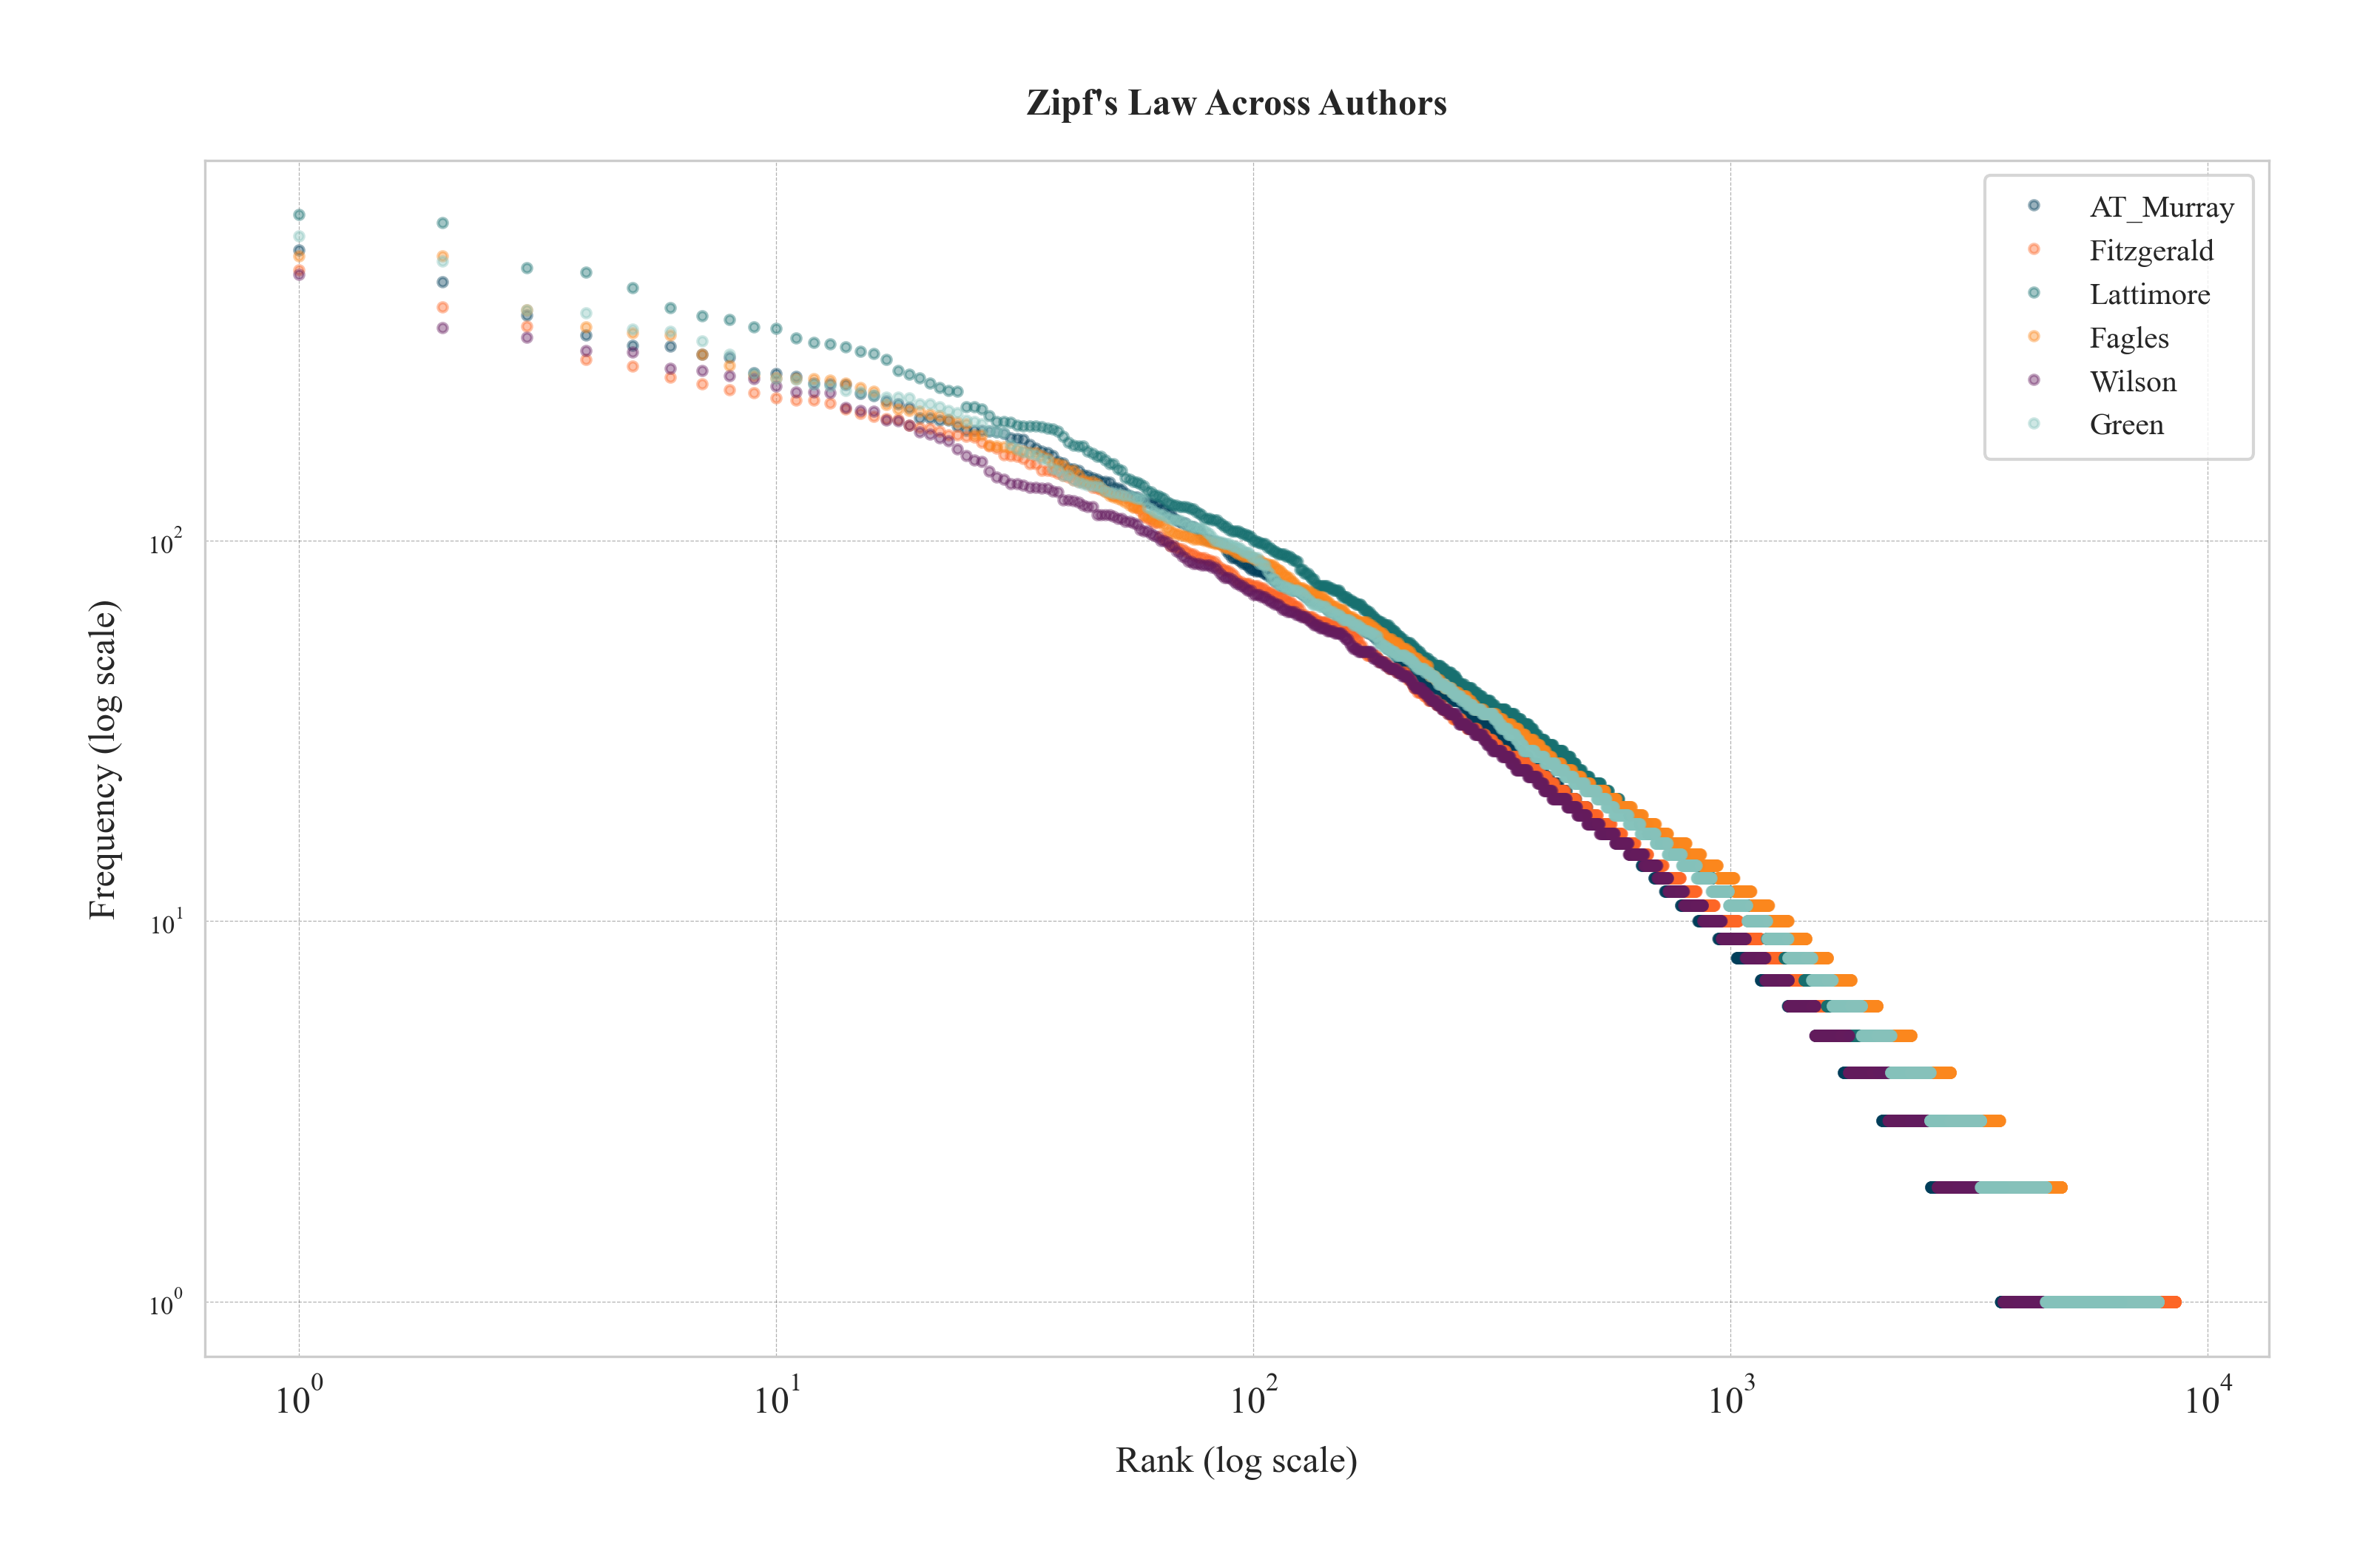

In [15]:
# Step 3: Zipf's Law Plot
def plot_zipfs_law(df_word_freq_rank_dict):

    for author, df_zipf in df_word_freq_rank_dict.items():
        plt.loglog(df_zipf["rank"], df_zipf["frequency"], label=author, marker=".", linestyle="None", alpha=0.4)

    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.title("Zipf's Law Across Authors")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.3, alpha=0.3)
    plt.show()

# Call the plotting function
plot_zipfs_law(df_word_freq_rank_dict)

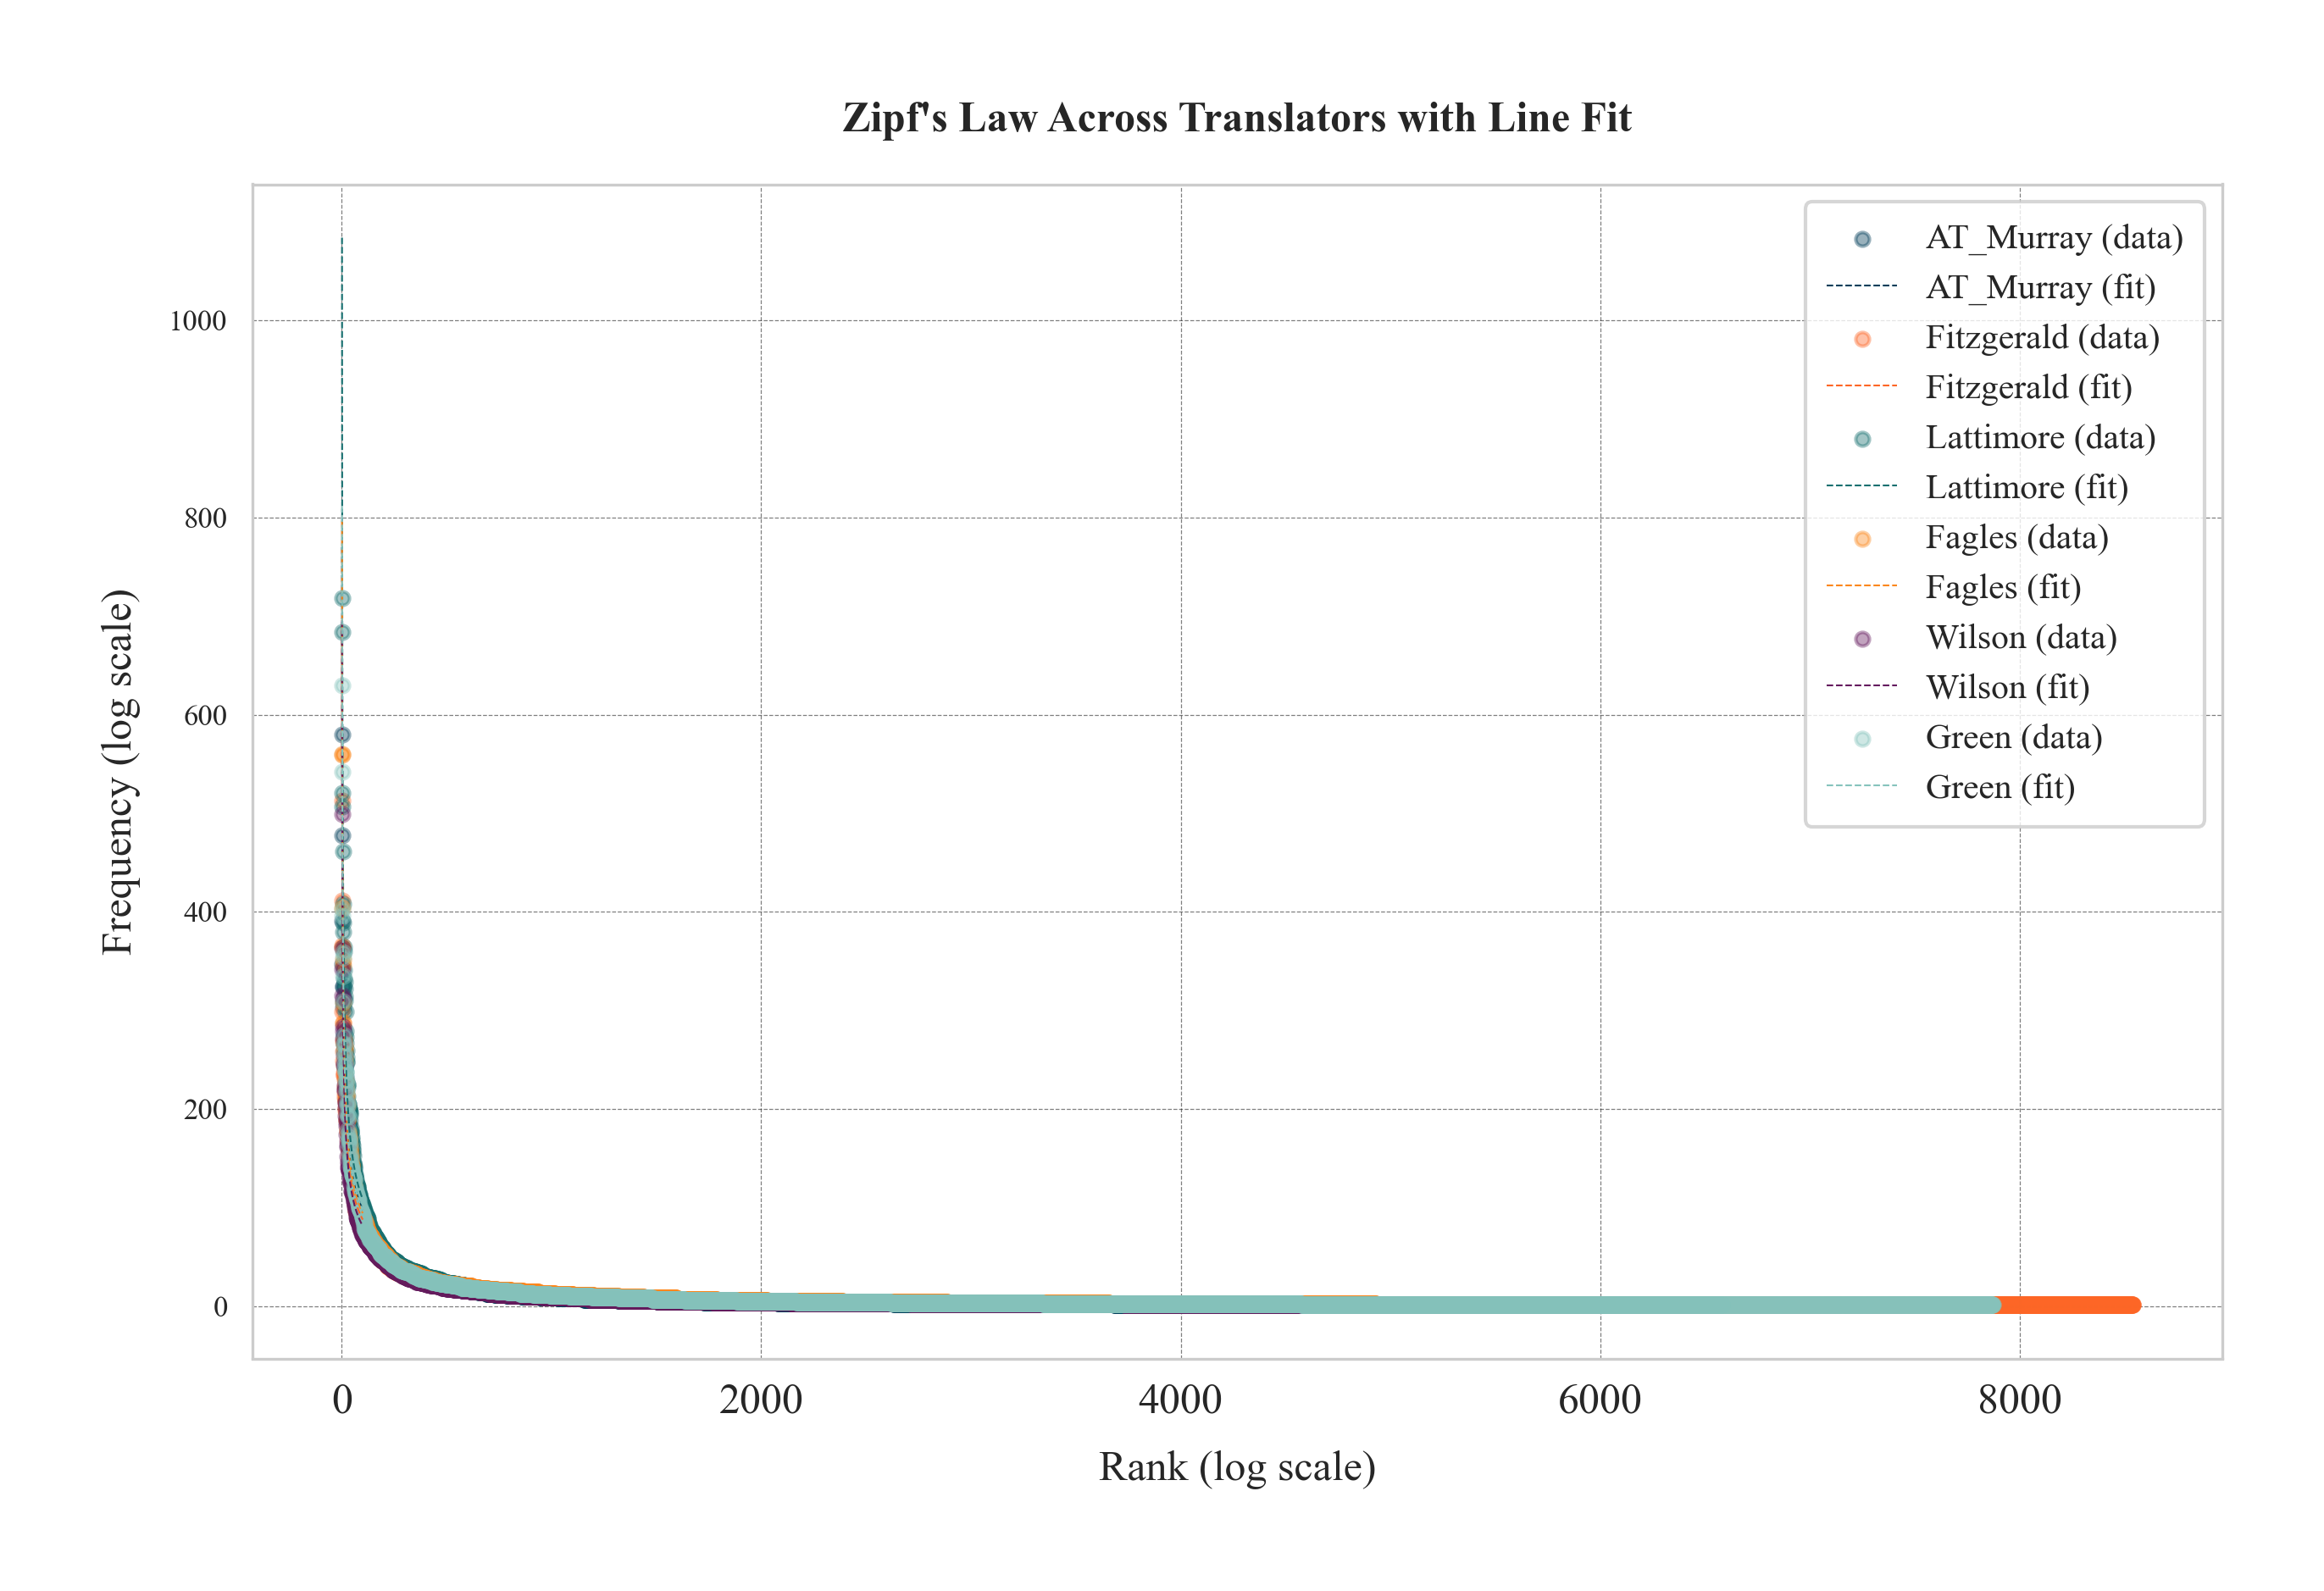

In [16]:
from sklearn.linear_model import LinearRegression
df_word_freq_rank_dict = {
    translator: pd.DataFrame(freq.items(), columns=["word", "frequency"])
    .sort_values(by="frequency", ascending=False)
    .assign(rank=lambda df_: df_["frequency"].rank(method="first", ascending=False))
    for translator, freq in freq_dict.items()
}

# Step 3: Zipf's Law Plot with Line Fit
def plot_zipfs_law_with_fit(df_word_freq_rank_dict):
    plt.figure(figsize=(10, 6))

    for translator, df_zipf in df_word_freq_rank_dict.items():
        # Get the top N most frequent words (extreme values)
        top_n = 100  # Adjust this number as needed to capture the most frequent words
        df_zipf_top = df_zipf.head(top_n)

        # Log-transform the rank and frequency for fitting
        x = np.log(df_zipf_top["rank"].values.reshape(-1, 1))  # Rank (log scale)
        y = np.log(df_zipf_top["frequency"].values)  # Frequency (log scale)

        # Fit a linear regression to the log-log data
        model = LinearRegression()
        model.fit(x, y)

        # Predict the line of best fit
        y_pred = model.predict(x)

        # Plot the scatter plot (log-log)
        plt.scatter(df_zipf["rank"], df_zipf["frequency"], label=f"{translator} (data)", alpha=0.4, s=15)

        # Plot the fitted line
        plt.plot(df_zipf_top["rank"], np.exp(y_pred), label=f"{translator} (fit)", linestyle='--', lw=.5)

    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.title("Zipf's Law Across Translators with Line Fit")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.3)
    plt.show()

# Call the plotting function
plot_zipfs_law_with_fit(df_word_freq_rank_dict)

In [17]:
# import linear regression function
from scipy.stats import linregress

# Create empty lists to store results
slopes = []
r_squared = []
p_values = []
std_errs = []
follows_zipf = []

# Perform linear regression in log-log space for each translator
for translator in translators:
    df_zipf = df_word_freq_rank_dict[translator]
    
    # Log-transform the rank and frequency
    #log_rank = np.log(df_zipf["rank"])
    #log_freq = np.log(df_zipf["frequency"])
    log_rank = np.log(df_zipf["rank"] + 1)  # Add a small constant to avoid log(0)
    log_freq = np.log(df_zipf["frequency"] + 1)
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(log_rank, log_freq)
    
    # Store results
    slopes.append(slope)
    r_squared.append(r_value**2)
    p_values.append(p_value)
    std_errs.append(std_err)
    follows_zipf.append(-1.2 < slope < -0.8)
    
    # Display individual results
    print(f"{translator}: Slope = {slope:.2f}, R² = {r_value**2:.3f}, p-value = {p_value:.3g}")
    
    # Check if slope is close to -1 (Zipf's Law predicts ~ -1)
    if -1.2 < slope < -0.8:
        print(f"{translator}'s translation follows Zipf's Law.")
    else:
        print(f"{translator}'s translation deviates from Zipf's Law.")
    print("-" * 50)

# Create a summary dataframe
results_df = pd.DataFrame({
    'Translator': translators,
    'Slope': slopes,
    'R²': r_squared,
    'p-value': p_values,
    'Std Error': std_errs,
    'Follows Zipf\'s Law': follows_zipf
})

print("\nSummary of Zipf's Law Analysis:")
print(results_df)


AT_Murray: Slope = -0.95, R² = 0.981, p-value = 0
AT_Murray's translation follows Zipf's Law.
--------------------------------------------------
Fitzgerald: Slope = -0.87, R² = 0.977, p-value = 0
Fitzgerald's translation follows Zipf's Law.
--------------------------------------------------
Lattimore: Slope = -1.00, R² = 0.981, p-value = 0
Lattimore's translation follows Zipf's Law.
--------------------------------------------------
Fagles: Slope = -0.93, R² = 0.981, p-value = 0
Fagles's translation follows Zipf's Law.
--------------------------------------------------
Wilson: Slope = -0.92, R² = 0.979, p-value = 0
Wilson's translation follows Zipf's Law.
--------------------------------------------------
Green: Slope = -0.93, R² = 0.981, p-value = 0
Green's translation follows Zipf's Law.
--------------------------------------------------

Summary of Zipf's Law Analysis:
  Translator   Slope  R²   p-value  Std Error  Follows Zipf's Law
0   AT_Murray -0.95  0.98 0.00     0.00        Tr

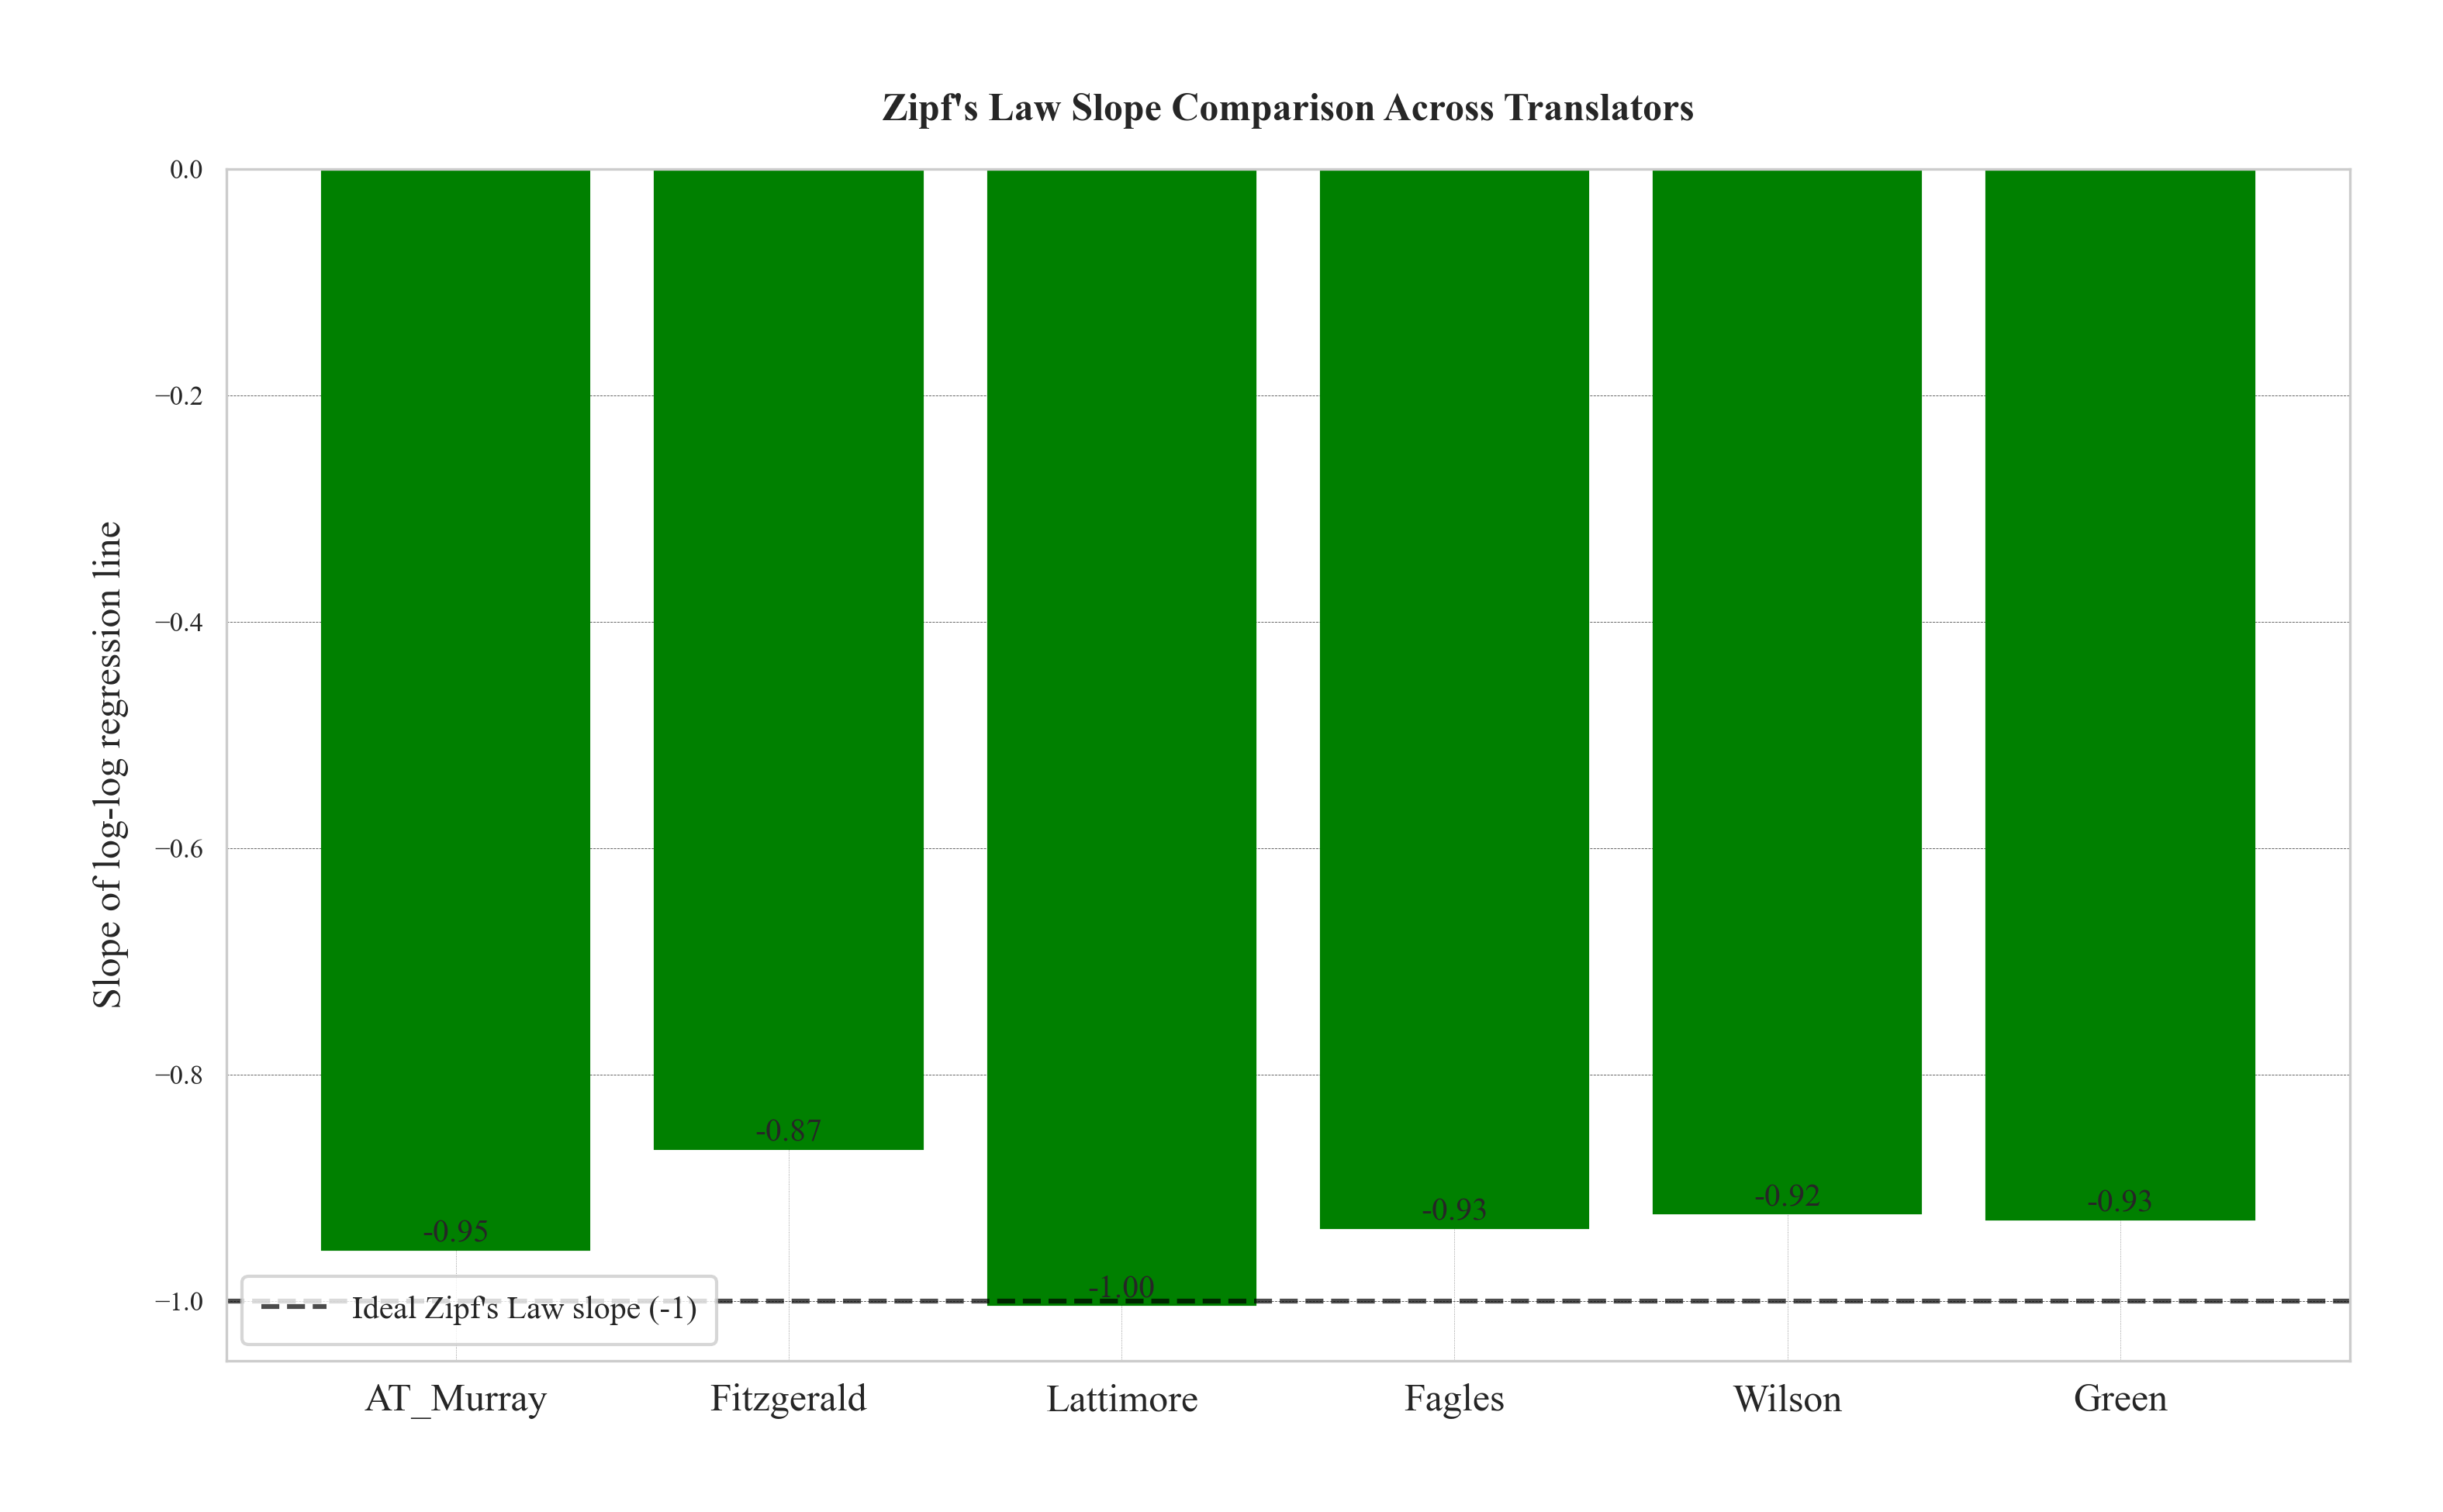

In [18]:
# Create a bar chart to visualize slopes
plt.figure(figsize=(10, 6))
bars = plt.bar(translators, slopes)

# Color the bars based on whether they follow Zipf's Law
for i, follows in enumerate(follows_zipf):
    bars[i].set_color('green' if follows else 'red')

# Add a horizontal line at -1 (ideal Zipf's Law slope)
plt.axhline(y=-1, color='black', linestyle='--', alpha=0.7, label="Ideal Zipf's Law slope (-1)")

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{slopes[i]:.2f}',
            ha='center', va='bottom' if height < 0 else 'top', 
            rotation=0)

plt.title("Zipf's Law Slope Comparison Across Translators")
plt.ylabel("Slope of log-log regression line")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
# Statistical comparison of slopes (using confidence intervals)
print("\nStatistical comparison of slopes:")
for i in range(len(translators)):
    for j in range(i+1, len(translators)):
        # Calculate standard error of the difference between slopes
        se_diff = np.sqrt(std_errs[i]**2 + std_errs[j]**2)
        
        # Calculate t-statistic
        t_stat = (slopes[i] - slopes[j]) / se_diff
        
        # Calculate degrees of freedom (approximation)
        d_freedom = len(df_word_freq_rank_dict[translators[i]]["rank"]) + len(df_word_freq_rank_dict[translators[j]]["rank"]) - 4
        
        # Calculate p-value
        from scipy.stats import t
        p_val = 2 * (1 - t.cdf(abs(t_stat), d_freedom))
        
        print(f"{translators[i]} vs {translators[j]}: Slope diff = {slopes[i]-slopes[j]:.3f}, p = {p_val:.4f}")
        if p_val < 0.05:
            print("   -> Statistically significant difference in slopes")
        else:
            print("   -> No statistically significant difference in slopes")


Statistical comparison of slopes:
AT_Murray vs Fitzgerald: Slope diff = -0.089, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Lattimore: Slope diff = 0.048, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Fagles: Slope diff = -0.019, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Wilson: Slope diff = -0.032, p = 0.0000
   -> Statistically significant difference in slopes
AT_Murray vs Green: Slope diff = -0.027, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Lattimore: Slope diff = 0.138, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Fagles: Slope diff = 0.070, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Wilson: Slope diff = 0.057, p = 0.0000
   -> Statistically significant difference in slopes
Fitzgerald vs Green: Slope diff = 0.062, p = 0.0000
   -> Statistically significant difference in slopes
Latt

One-Way ANOVA (Single Test for All Translators)

The ANOVA test is used when you want to compare the means of more than two groups—in this case, the slopes of the different translators. This will tell you if there are any significant differences between the slopes across all translators.


In [20]:
# Slopes for each translator
slopes = results_df["Slope"]
type(slopes)

pandas.core.series.Series

In [21]:
slopes = dict(zip(results_df['Translator'], results_df['Slope']))
slopes

{'AT_Murray': -0.9542932093576058,
 'Fitzgerald': -0.8650585004530146,
 'Lattimore': -1.0027317864449838,
 'Fagles': -0.9349911474605519,
 'Wilson': -0.9224031857694105,
 'Green': -0.9273243258759374}

t-test pairwise comparison:

In [22]:
import numpy as np
from scipy.stats import ttest_ind
#t-test pairwise comparison:
# Slope values for each translator (from the results_df generated earlier)
slopes = {
    'AT_Murray': -1.17,
    'Fitzgerald': -1.08,
    'Lattimore': -1.21,
    'Fagles': -1.14,
    'Wilson': -1.14,
    'Green': -1.14
}

# Convert dictionary to a list of slopes
slope_values = list(slopes.values())

# Perform pairwise t-tests for differences in slopes
for i in range(len(slope_values)):
    for j in range(i+1, len(slope_values)):
        translator_1 = list(slopes.keys())[i]
        translator_2 = list(slopes.keys())[j]
        
        # Compare slopes for translator_1 and translator_2
        t_stat, p_value = ttest_ind([slope_values[i]], [slope_values[j]])

        # Interpretation
        print(f"Comparison: {translator_1} vs {translator_2}")
        print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.5f}")
        
        if p_value < 0.05:
            print(f"  -> There is a significant difference in slopes between {translator_1} and {translator_2}.")
        else:
            print(f"  -> No significant difference in slopes between {translator_1} and {translator_2}.")
        print("-" * 50)

Comparison: AT_Murray vs Fitzgerald
T-statistic: nan, P-value: nan
  -> No significant difference in slopes between AT_Murray and Fitzgerald.
--------------------------------------------------
Comparison: AT_Murray vs Lattimore
T-statistic: nan, P-value: nan
  -> No significant difference in slopes between AT_Murray and Lattimore.
--------------------------------------------------
Comparison: AT_Murray vs Fagles
T-statistic: nan, P-value: nan
  -> No significant difference in slopes between AT_Murray and Fagles.
--------------------------------------------------
Comparison: AT_Murray vs Wilson
T-statistic: nan, P-value: nan
  -> No significant difference in slopes between AT_Murray and Wilson.
--------------------------------------------------
Comparison: AT_Murray vs Green
T-statistic: nan, P-value: nan
  -> No significant difference in slopes between AT_Murray and Green.
--------------------------------------------------
Comparison: Fitzgerald vs Lattimore
T-statistic: nan, P-value: 

/Users/debr/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:7030: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df


ANOVA F-statistic: nan, P-value: nan
No statistically significant difference in Zipf's Law slopes across translators.


/Users/debr/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4141: DegenerateDataWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  warnings.warn(stats.DegenerateDataWarning(msg))


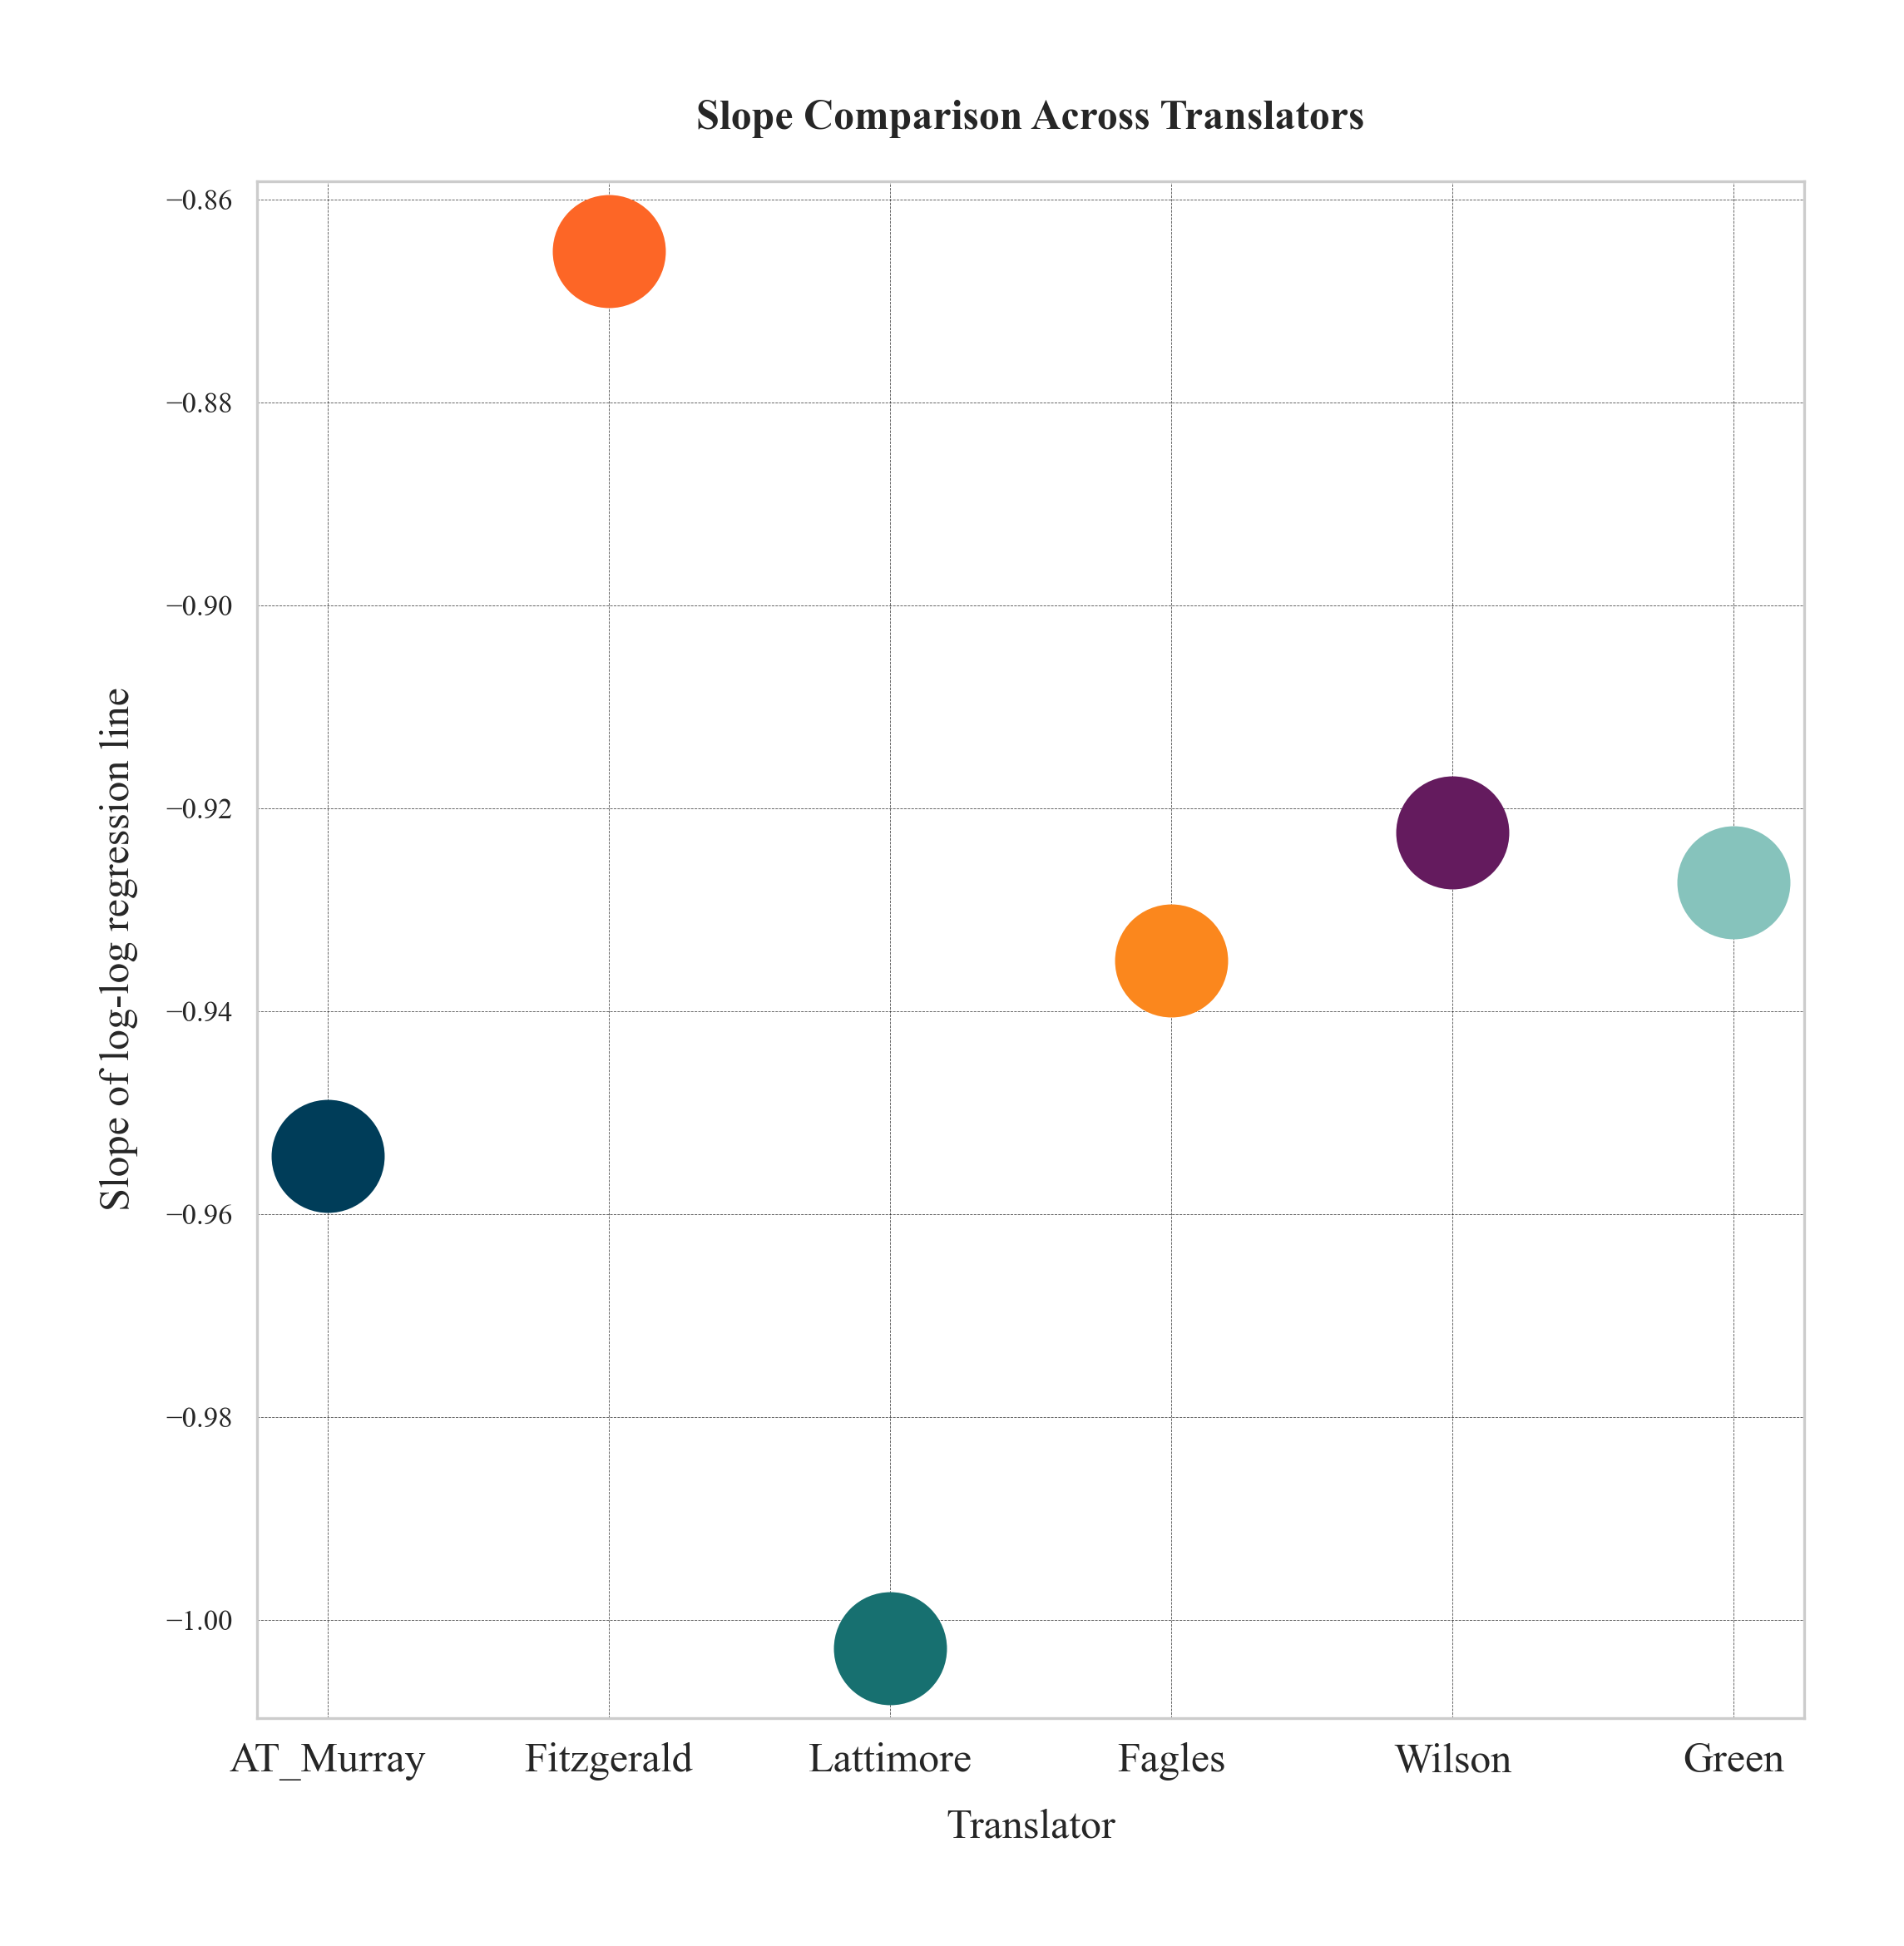

In [23]:
# Assuming you have a separate df that contains 'book_num' and other book-level info
# Add book_num into df_word_freq_rank_dict so you can filter it properly later.

# Initialize a dictionary to store slopes for each translator's books
slopes_by_translator = {translator: [] for translator in df['translator'].unique()}

# Loop through each row in the dataframe `df` to calculate the slope for each book
for index, row in df.iterrows():
    translator = row['translator']
    book_num = row['book_num']  # Extract the book number from `df`
    
    # Access the corresponding dataframe for the translator's Zipf data in df_word_freq_rank_dict
    df_zipf = df_word_freq_rank_dict[translator]
    
    # Check if 'book_num' is part of the `df_zipf` or if you need to manually map it
    if 'book_num' not in df_zipf.columns:
        # Create a new column for book_num if it's not already in df_zipf (assuming you have book_num info in df)
        df_zipf['book_num'] = [book_num] * len(df_zipf)
    
    # Filter data for this book (by translator and book_num)
    df_book = df_zipf[df_zipf['book_num'] == book_num]
    
    # If there are rows for the book, calculate the slope
    if not df_book.empty:
        # Log-transform the rank and frequency
        log_rank = np.log(df_book["rank"] + 1)  # Add 1 to avoid log(0)
        log_freq = np.log(df_book["frequency"] + 1)  # Add 1 to avoid log(0)
        
        # Perform linear regression on the log-log space
        slope, intercept, r_value, p_value, std_err = linregress(log_rank, log_freq)
        
        # Store the slope for this translator and book
        slopes_by_translator[translator].append(slope)

# Now that we have the slopes per translator, let's create a summary for the ANOVA test
slope_groups = [slopes_by_translator[translator] for translator in slopes_by_translator]

# Perform One-Way ANOVA
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(*slope_groups)

# Print the results
print(f"ANOVA F-statistic: {f_stat:.3f}, P-value: {p_value:.5f}")

# Interpretation of ANOVA results
if p_value < 0.05:
    print("There is a statistically significant difference in Zipf's Law slopes across translators.")
else:
    print("No statistically significant difference in Zipf's Law slopes across translators.")

# Optional: Visualizing the slopes per translator
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for translator, slopes in slopes_by_translator.items():
    plt.scatter([translator] * len(slopes), slopes, label=translator, s=1000)

plt.title("Slope Comparison Across Translators")
plt.ylabel("Slope of log-log regression line")
plt.xlabel("Translator")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks()
#plt.legend()

plt.show()            


In [24]:
e.check_df(df)

Oh, yeah! No missing values here!

* df columns: Index(['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens'], dtype='object') 

* Shape: (144, 6) 

* Total memory: 3.490719


In [25]:
import pandas as pd
import numpy as np

# Assuming you have the following dataframe df:
# df = pd.DataFrame(...)

# Create a function to calculate Zipf's law for each book and author
def calculate_zipf(row):
    # Tokenize the 'text' column (assuming words are space-separated)
    words = row['tokens']  # Use the list of tokens directly
    
    # Calculate frequency of each word
    word_freq = pd.Series(words).value_counts()
    
    # Rank words based on frequency (most frequent gets rank 1)
    word_freq = word_freq.sort_values(ascending=False)
    
    # Rank is the index of the sorted values (this is the Zipf rank)
    ranks = np.log(np.arange(1, len(word_freq) + 1))  # Zipf's Law ranks, log scale
    
    # Compute Zipf's law score: Rank vs. Frequency relationship
    log_freq = np.log(word_freq.values + 1)  # Log-transform frequency (to avoid log(0))
    log_rank = np.log(ranks + 1)  # Log-transform rank (to avoid log(0))
    
    # You can use linear regression or other methods to compute the Zipf slope, or just save the rank values.
    # For simplicity, I will return the Zipf rank.
    
    return log_rank, log_freq  # You can modify what you want to return (rank, frequency, slope, etc.)

# Apply this function to each row in the df
df['zipf'] = df.apply(calculate_zipf, axis=1)

# The result will be a tuple, you may want to expand it into two separate columns (for rank and frequency):
df[['zipf_rank', 'zipf_freq']] = pd.DataFrame(df['zipf'].tolist(), index=df.index)

# If you want to combine both values into a single "zipf" column, you can do that as well:
df['zipf'] = df['zipf_rank'] - df['zipf_freq']  # or any other combination you need

# View the result
print(df[['zipf', 'zipf_rank', 'zipf_freq']].head())

  zipf                                                                                                                                                                                                     zipf_rank                                                                                                                                                                                                zipf_freq                                                                                                                                                                                               
0  [-3.258096538021482, -2.4691432394149464, -2.2031626677914247, -2.0746972929744962, -1.9312369189753404, -1.8636997266971136, -1.8099539396231767, -1.647840459330745, -1.5457670872182097, -1.51334...  [0.0, 0.5265890341390446, 0.7412763113750154, 0.8697416861919439, 0.959134838920824, 1.026672031199051, 1.0804178182729878, 1.1247482629090362, 1.1622831138840004, 1.1947055233182955, 1.22315

In [26]:
len(df['zipf'][0])

881

In [27]:
len(set(df['tokens'][0]))

881

In [28]:
import scipy.stats as stats

# Ensure all groups have more than one value
zipf_groups = df.groupby("translator")["zipf"].apply(list).values
zipf_rank_groups = df.groupby("translator")["zipf_rank"].apply(list).values
zipf_freq_groups = df.groupby("translator")["zipf_freq"].apply(list).values

def perform_anova(groups, label):
    # Check if there are at least two non-empty groups with more than one value
    valid_groups = [g for g in groups if len(g) > 1]
    if len(valid_groups) > 1:
        f_stat, p_value = stats.f_oneway(*valid_groups)
        print(f"ANOVA for {label}: F = {f_stat:.3f}, p = {p_value:.5f}")
    else:
        print(f"Not enough data for ANOVA on {label}.")

# Perform ANOVA for each metric
perform_anova(zipf_groups, "Zipf Slopes")
perform_anova(zipf_rank_groups, "Zipf Rank")
perform_anova(zipf_freq_groups, "Zipf Frequency")

/var/folders/ry/hrln400n23ldv0p0lx1m14140000gn/T/ipykernel_19704/2966396768.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zipf_groups = df.groupby("translator")["zipf"].apply(list).values
/var/folders/ry/hrln400n23ldv0p0lx1m14140000gn/T/ipykernel_19704/2966396768.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zipf_rank_groups = df.groupby("translator")["zipf_rank"].apply(list).values
/var/folders/ry/hrln400n23ldv0p0lx1m14140000gn/T/ipykernel_19704/2966396768.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (24,) + inhomogeneous part.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Assuming you already have your DataFrame (df) and the 'zipf' columns are calculated

# Define a function for bootstrapping the slope
def bootstrap_slope(df, n_bootstrap=1000):
    slopes_bootstrap = []
    
    for _ in range(n_bootstrap):
        # Sample data with replacement
        bootstrap_sample = df.sample(n=len(df), replace=True)
        
        # Get the log-transformed rank and frequency
        log_rank = np.log(bootstrap_sample['rank'] + 1)  # Avoid log(0)
        log_freq = np.log(bootstrap_sample['frequency'] + 1)
        
        # Perform linear regression on the bootstrap sample
        slope, intercept, r_value, p_value, std_err = linregress(log_rank, log_freq)
        
        # Store the slope
        slopes_bootstrap.append(slope)
    
    # Convert to a numpy array for easier analysis
    slopes_bootstrap = np.array(slopes_bootstrap)
    
    # Calculate 95% confidence intervals
    lower_bound = np.percentile(slopes_bootstrap, 2.5)
    upper_bound = np.percentile(slopes_bootstrap, 97.5)
    
    # Return the distribution of slopes and the confidence intervals
    return slopes_bootstrap, lower_bound, upper_bound

# Now, let's apply the bootstrap for each author
bootstrap_results = {}
for translator in translators:
    df_translator = df_word_freq_rank_dict[translator]
    
    # Run the bootstrap procedure
    slopes_bootstrap, lower_bound, upper_bound = bootstrap_slope(df_translator, n_bootstrap=1000)
    
    # Store the results
    bootstrap_results[translator] = {
        'bootstrap_slopes': slopes_bootstrap,
        '95% CI Lower Bound': lower_bound,
        '95% CI Upper Bound': upper_bound
    }

# Print results
for translator, result in bootstrap_results.items():
    print(f"{translator}:")
    print(f"  95% CI for slope: ({result['95% CI Lower Bound']:.4f}, {result['95% CI Upper Bound']:.4f})")
    print(f"  Mean slope: {np.mean(result['bootstrap_slopes']):.4f}")
    print("-" * 50)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot
plt.figure(figsize=(12, 8))

# Plot bootstrap distributions for each translator
for translator, result in bootstrap_results.items():
    sns.histplot(result['bootstrap_slopes'], bins=30, kde=True, label=translator, alpha=0.6)

# Formatting
plt.xlabel("Bootstrap Slope")
plt.ylabel("Frequency")
plt.title("Distribution of Bootstrapped Slopes for Each Translator")
plt.legend()
plt.show()

In [ ]:
# Create a DataFrame with confidence intervals for easy comparison
ci_df = pd.DataFrame({
    'Translator': list(bootstrap_results.keys()),
    'Mean Slope': [np.mean(res['bootstrap_slopes']) for res in bootstrap_results.values()],
    '95% CI Lower Bound': [res['95% CI Lower Bound'] for res in bootstrap_results.values()],
    '95% CI Upper Bound': [res['95% CI Upper Bound'] for res in bootstrap_results.values()]
})

# Display the results
print("\nBootstrap Confidence Intervals for Slopes:")
print(ci_df)

Interpreting the Bootstrap Confidence Intervals for Zipf’s Law Slopes

The bootstrap analysis provides estimated confidence intervals for the Zipf’s Law slopes of different translators, allowing us to assess the variation and potential differences between them. Here’s what the results indicate:

1.	Mean Slope Differences:
•	Lattimore has the steepest slope (-1.00), suggesting a stronger adherence to Zipf’s Law.
•	Fitzgerald has the shallowest slope (-0.87), meaning a weaker adherence to Zipf’s Law.
•	The other translators fall between these two extremes, with slopes ranging from -0.93 to -0.95.

2.	Confidence Interval Overlaps:
•	The confidence intervals (CIs) provide a range of likely values for each translator’s slope.
•	There is substantial overlap among the CIs of AT_Murray, Fagles, Wilson, and Green, suggesting their slopes are quite similar.
•	Fitzgerald’s CI does not overlap much with Lattimore’s, indicating a notable difference in their adherence to Zipf’s Law.

3.	Statistical Significance & Interpretation:
•	The ANOVA test (if significant) would confirm whether the differences in slopes are statistically meaningful.
•	If ANOVA is not significant, the differences we observe may be due to natural variation rather than a real effect.
•	A post-hoc test (Tukey HSD) would help identify specific pairs of translators whose slopes differ significantly.

Conclusions & Next Steps
	•	Translators like Lattimore seem to follow Zipf’s Law more closely than Fitzgerald, who has the shallowest slope.
	•	If the confidence intervals overlap significantly, we may conclude that most translators exhibit similar word frequency distributions despite stylistic differences.
	•	Further analysis could examine slopes within individual books, rather than averaging across a translator’s entire corpus, to see if variability exists within a translator’s works.

Would you like a deeper statistical comparison between specific translators? 🚀

In [ ]:
from scipy.stats import linregress
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# List of translator names and their dataframes
translators = ["AT_Murray", "Fitzgerald", "Lattimore", "Fagles", "Wilson", "Green"]
zipf_dfs = [df_zipf_at_murray, df_zipf_fitzgerald, df_zipf_lattimore, df_zipf_fagles, df_zipf_wilson, df_zipf_green]

# Create empty lists to store results
slopes = []
r_squared = []
p_values = []
std_errs = []
follows_zipf = []

# Perform linear regression in log-log space for each translator
for i, translator in enumerate(translators):
    log_rank = np.log(zipf_dfs[i]["rank"])
    log_freq = np.log(zipf_dfs[i]["frequency"])
    slope, intercept, r_value, p_value, std_err = linregress(log_rank, log_freq)
    
    # Store results
    slopes.append(slope)
    r_squared.append(r_value**2)
    p_values.append(p_value)
    std_errs.append(std_err)
    follows_zipf.append(-1.2 < slope < -0.8)
    
    # Display individual results
    print(f"{translator}: Slope = {slope:.2f}, R² = {r_value**2:.3f}, p-value = {p_value:.3g}")
    
    # Check if slope is close to -1 (Zipf's Law predicts ~ -1)
    if -1.2 < slope < -0.8:
        print(f"{translator}'s translation follows Zipf's Law.")
    else:
        print(f"{translator}'s translation deviates from Zipf's Law.")
    print("-" * 50)

# Create a summary dataframe
results_df = pd.DataFrame({
    'Translator': translators,
    'Slope': slopes,
    'R²': r_squared,
    'p-value': p_values,
    'Std Error': std_errs,
    'Follows Zipf\'s Law': follows_zipf
})

print("\nSummary of Zipf's Law Analysis:")
print(results_df)

# Create a bar chart to visualize slopes
plt.figure(figsize=(10, 6))
bars = plt.bar(translators, slopes)

# Color the bars based on whether they follow Zipf's Law
for i, follows in enumerate(follows_zipf):
    bars[i].set_color('green' if follows else 'red')

# Add a horizontal line at -1 (ideal Zipf's Law slope)
plt.axhline(y=-1, color='black', linestyle='--', alpha=0.7, label="Ideal Zipf's Law slope (-1)")

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{slopes[i]:.2f}',
            ha='center', va='bottom' if height < 0 else 'top', 
            rotation=0)

plt.title("Zipf's Law Slope Comparison Across Translators")
plt.ylabel("Slope of log-log regression line")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig(f"{output_path_plots}/Zipf_slope_comparison.png", dpi=300)
plt.show()

# Statistical comparison of slopes (using confidence intervals)
print("\nStatistical comparison of slopes:")
for i in range(len(translators)):
    for j in range(i+1, len(translators)):
        # Calculate standard error of the difference between slopes
        se_diff = np.sqrt(std_errs[i]**2 + std_errs[j]**2)
        
        # Calculate t-statistic
        t_stat = (slopes[i] - slopes[j]) / se_diff
        
        # Calculate degrees of freedom (approximation)
        d_freedom = len(zipf_dfs[i]["rank"]) + len(zipf_dfs[j]["rank"]) - 4
        
        # Calculate p-value
        from scipy.stats import t
        p_val = 2 * (1 - t.cdf(abs(t_stat), d_freedom))
        
        print(f"{translators[i]} vs {translators[j]}: Slope diff = {slopes[i]-slopes[j]:.3f}, p = {p_val:.4f}")
        if p_val < 0.05:
            print("   -> Statistically significant difference in slopes")
        else:
            print("   -> No statistically significant difference in slopes")